# Inspect Top Anomalies
For each top-k provider by anomaly score:
- NPPES identity info (name, state, zip)
- Find the provider-month feature group with highest reconstruction error
- Plot that feature over time vs. normal peers (median reconstruction error, non-LEIE)

In [55]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

In [ ]:
# ── Paths — edit these ────────────────────────────────────────────────────
NPPES_CSV            = "../data/datasets/nppes.csv"
PROVIDER_MONTH_CSV   = "../data/outputs/provider_month_NV_organization.csv"
SCORED_CSV           = "../data/outputs/2026-03-22_23-15-56/scored_providers.csv"
FEAT_ERRORS_CSV      = "../data/outputs/2026-03-22_23-15-56/provider_feature_errors.csv"
PROVIDER_LEVEL_DATSET = "../data/outputs/2026-03-21_22-57-39/provider_level.csv" 
TARGET_NPI     = "1649949124"   # NPI to inspect (must exist in scored_providers.csv)



In [57]:
df = pd.read_csv(PROVIDER_MONTH_CSV)
df['paid_per_beneficiary_proxy_t'].describe()

count    164849.000000
mean        226.897789
std         470.860098
min           0.000000
25%          30.349356
50%          66.452500
75%         191.333333
max       13206.105263
Name: paid_per_beneficiary_proxy_t, dtype: float64

In [58]:
con = duckdb.connect()

scored = pd.read_csv(SCORED_CSV)
scored["billing_provider_npi"] = scored["billing_provider_npi"].astype(str)

row = scored[scored["billing_provider_npi"] == TARGET_NPI]
if row.empty:
    raise ValueError(f"NPI {TARGET_NPI} not found in scored_providers.csv")

target_row = row.iloc[0]
npi_list = f"'{TARGET_NPI}'"

print(f"NPI:           {TARGET_NPI}")
print(f"Anomaly score: {target_row['anomaly_score']:.4f}")
print(f"Label:         {int(target_row['label'])} ({'LEIE' if target_row['label'] == 1 else 'normal'})")


NPI:           1649949124
Anomaly score: 1.5452
Label:         1 (LEIE)


In [59]:
# ── NPPES full record for TARGET_NPI ─────────────────────────────────────
raw = con.execute(f"""
    SELECT *,
        CASE
            WHEN "Healthcare Provider Primary Taxonomy Switch_1"  = 'Y' THEN "Healthcare Provider Taxonomy Code_1"
            WHEN "Healthcare Provider Primary Taxonomy Switch_2"  = 'Y' THEN "Healthcare Provider Taxonomy Code_2"
            WHEN "Healthcare Provider Primary Taxonomy Switch_3"  = 'Y' THEN "Healthcare Provider Taxonomy Code_3"
            WHEN "Healthcare Provider Primary Taxonomy Switch_4"  = 'Y' THEN "Healthcare Provider Taxonomy Code_4"
            WHEN "Healthcare Provider Primary Taxonomy Switch_5"  = 'Y' THEN "Healthcare Provider Taxonomy Code_5"
            WHEN "Healthcare Provider Primary Taxonomy Switch_6"  = 'Y' THEN "Healthcare Provider Taxonomy Code_6"
            WHEN "Healthcare Provider Primary Taxonomy Switch_7"  = 'Y' THEN "Healthcare Provider Taxonomy Code_7"
            WHEN "Healthcare Provider Primary Taxonomy Switch_8"  = 'Y' THEN "Healthcare Provider Taxonomy Code_8"
            WHEN "Healthcare Provider Primary Taxonomy Switch_9"  = 'Y' THEN "Healthcare Provider Taxonomy Code_9"
            WHEN "Healthcare Provider Primary Taxonomy Switch_10" = 'Y' THEN "Healthcare Provider Taxonomy Code_10"
            WHEN "Healthcare Provider Primary Taxonomy Switch_11" = 'Y' THEN "Healthcare Provider Taxonomy Code_11"
            WHEN "Healthcare Provider Primary Taxonomy Switch_12" = 'Y' THEN "Healthcare Provider Taxonomy Code_12"
            WHEN "Healthcare Provider Primary Taxonomy Switch_13" = 'Y' THEN "Healthcare Provider Taxonomy Code_13"
            WHEN "Healthcare Provider Primary Taxonomy Switch_14" = 'Y' THEN "Healthcare Provider Taxonomy Code_14"
            WHEN "Healthcare Provider Primary Taxonomy Switch_15" = 'Y' THEN "Healthcare Provider Taxonomy Code_15"
            ELSE "Healthcare Provider Taxonomy Code_1"
        END AS primary_taxonomy_code
    FROM read_csv_auto('{NPPES_CSV}', ignore_errors=true)
    WHERE CAST("NPI" AS VARCHAR) = '{TARGET_NPI}'
""").df()

if raw.empty:
    raise ValueError(f"NPI {TARGET_NPI} not found in NPPES")

# Keep only columns with a non-null, non-empty value for this provider
first_row = raw.iloc[0]
keep_cols = [c for c in raw.columns
             if pd.notna(first_row[c]) and str(first_row[c]).strip() != ""]
target_nppes = raw[keep_cols].copy()
target_nppes["NPI"] = target_nppes["NPI"].astype(str)

# ── Append model output columns ───────────────────────────────────────────
pct = (scored["anomaly_score"] < target_row["anomaly_score"]).mean() * 100
target_nppes["anomaly_score"]      = round(float(target_row["anomaly_score"]), 4)
target_nppes["anomaly_percentile"] = round(pct, 1)
target_nppes["leie_label"]         = int(target_row["label"])  # 1 = LEIE excluded

print(f"NPI {TARGET_NPI} — {len(target_nppes.columns)} columns (NPPES + model)")
display(target_nppes.T.rename(columns={0: "value"}))


NPI 1649949124 — 29 columns (NPPES + model)


,value
NPI,1649949124
Entity Type Code,2
Employer Identification Number (EIN),<UNAVAIL>
Provider Organization Name (Legal Business Name),NEVADA STATE FAMILY SERVICES LLC
Provider First Line Business Mailing Address,3053 W CRAIG RD UNIT E-288
Provider Business Mailing Address City Name,NORTH LAS VEGAS
Provider Business Mailing Address State Name,NV
Provider Business Mailing Address Postal Code,890325124
Provider Business Mailing Address Country Code (If outside U.S.),US
Provider First Line Business Practice Location Address,4760 S PECOS RD STE 103-25


In [66]:
# ── Provider-level feature comparison: TARGET_NPI vs same-taxonomy peers ──
# Load provider-level actual feature values
prov_level = pd.read_csv(PROVIDER_LEVEL_DATSET)
prov_level["billing_provider_npi"] = prov_level["billing_provider_npi"].astype(str)

# Resolve primary taxonomy for TARGET_NPI — guard against NaN
_tax_raw = target_nppes.iloc[0].get("primary_taxonomy_code")
target_taxonomy = None if (pd.isna(_tax_raw) or str(_tax_raw).strip() == "") else str(_tax_raw).strip()

# Resolve primary taxonomy for all providers in feat_err via DuckDB join on NPPES
con.register("feat_err_duck", feat_err)
feat_with_tax = con.execute(f"""
    SELECT f.billing_provider_npi,
        CASE
            WHEN n."Healthcare Provider Primary Taxonomy Switch_1"  = 'Y' THEN n."Healthcare Provider Taxonomy Code_1"
            WHEN n."Healthcare Provider Primary Taxonomy Switch_2"  = 'Y' THEN n."Healthcare Provider Taxonomy Code_2"
            WHEN n."Healthcare Provider Primary Taxonomy Switch_3"  = 'Y' THEN n."Healthcare Provider Taxonomy Code_3"
            WHEN n."Healthcare Provider Primary Taxonomy Switch_4"  = 'Y' THEN n."Healthcare Provider Taxonomy Code_4"
            WHEN n."Healthcare Provider Primary Taxonomy Switch_5"  = 'Y' THEN n."Healthcare Provider Taxonomy Code_5"
            WHEN n."Healthcare Provider Primary Taxonomy Switch_6"  = 'Y' THEN n."Healthcare Provider Taxonomy Code_6"
            WHEN n."Healthcare Provider Primary Taxonomy Switch_7"  = 'Y' THEN n."Healthcare Provider Taxonomy Code_7"
            WHEN n."Healthcare Provider Primary Taxonomy Switch_8"  = 'Y' THEN n."Healthcare Provider Taxonomy Code_8"
            WHEN n."Healthcare Provider Primary Taxonomy Switch_9"  = 'Y' THEN n."Healthcare Provider Taxonomy Code_9"
            WHEN n."Healthcare Provider Primary Taxonomy Switch_10" = 'Y' THEN n."Healthcare Provider Taxonomy Code_10"
            WHEN n."Healthcare Provider Primary Taxonomy Switch_11" = 'Y' THEN n."Healthcare Provider Taxonomy Code_11"
            WHEN n."Healthcare Provider Primary Taxonomy Switch_12" = 'Y' THEN n."Healthcare Provider Taxonomy Code_12"
            WHEN n."Healthcare Provider Primary Taxonomy Switch_13" = 'Y' THEN n."Healthcare Provider Taxonomy Code_13"
            WHEN n."Healthcare Provider Primary Taxonomy Switch_14" = 'Y' THEN n."Healthcare Provider Taxonomy Code_14"
            WHEN n."Healthcare Provider Primary Taxonomy Switch_15" = 'Y' THEN n."Healthcare Provider Taxonomy Code_15"
        END AS primary_taxonomy_code
    FROM feat_err_duck f
    LEFT JOIN read_csv_auto('{NPPES_CSV}', ignore_errors=true) n
        ON CAST(n."NPI" AS VARCHAR) = f.billing_provider_npi
""").df()
feat_with_tax["billing_provider_npi"] = feat_with_tax["billing_provider_npi"].astype(str)

# Peer NPIs: same non-null taxonomy, excluding TARGET_NPI
if target_taxonomy:
    peer_mask = (
        (feat_with_tax["primary_taxonomy_code"].notna()) &
        (feat_with_tax["primary_taxonomy_code"] == target_taxonomy) &
        (feat_with_tax["billing_provider_npi"] != TARGET_NPI)
    )
    peer_npis = set(feat_with_tax.loc[peer_mask, "billing_provider_npi"])
else:
    peer_npis = set()

# TARGET_NPI actual feature values (provider_level.csv)
target_prov_row = prov_level[prov_level["billing_provider_npi"] == TARGET_NPI]
if target_prov_row.empty:
    raise ValueError(f"TARGET_NPI {TARGET_NPI} not found in PROVIDER_LEVEL_DATSET")
target_prov_vals = target_prov_row.iloc[0].reindex(err_features)

# Peer actual feature values (provider_level.csv)
peers_prov = prov_level[prov_level["billing_provider_npi"].isin(peer_npis)]
peer_val_medians = (
    peers_prov.reindex(columns=err_features).median()
    if len(peers_prov) > 0
    else pd.Series(float("nan"), index=err_features)
)

# TARGET_NPI reconstruction errors (feat_err)
target_err_row = feat_err[feat_err["billing_provider_npi"] == TARGET_NPI][err_features]
if target_err_row.empty:
    raise ValueError(f"TARGET_NPI {TARGET_NPI} not found in feat_err")
target_err_vals = target_err_row.iloc[0]

# Peer reconstruction errors (feat_err)
peers_err = feat_err[feat_err["billing_provider_npi"].isin(peer_npis)][err_features]
peer_err_medians = (
    peers_err.median()
    if len(peers_err) > 0
    else pd.Series(float("nan"), index=err_features)
)

feat_comparison = pd.DataFrame({
    "feature_value":     target_prov_vals,   # TARGET_NPI actual value (PROVIDER_LEVEL_DATSET)
    "peer_median_value": peer_val_medians,   # peer median actual value (PROVIDER_LEVEL_DATSET)
    "recon_error":       target_err_vals,    # TARGET_NPI reconstruction error (FEAT_ERRORS_CSV)
    "peer_median_recon": peer_err_medians,   # peer median reconstruction error (FEAT_ERRORS_CSV)
}).round(4).sort_values("recon_error", ascending=False)
feat_comparison.index.name = "feature"

n_peers = len(peer_npis)
tax_str = target_taxonomy or "N/A (no primary taxonomy found)"
if n_peers == 0:
    print(f"Taxonomy: {tax_str}  |  no peers with same primary taxonomy — peer medians = NaN")
else:
    print(f"Taxonomy: {tax_str}  |  {n_peers} peers with same primary taxonomy")
display(feat_comparison)


Taxonomy: 261QP2300X  |  39 peers with same primary taxonomy


,feature_value,peer_median_value,recon_error,peer_median_recon
feature,,,,
paid_per_beneficiary_proxy_t_q25,5730.709333,46.6137,8.6738,0.0964
paid_per_beneficiary_proxy_t_median,6113.965,55.8454,6.7836,0.0932
paid_per_beneficiary_proxy_t_mean,6132.733214,55.5515,6.6402,0.0927
paid_per_beneficiary_proxy_t_median_abs_monthlyized_change,1001.691593,7.3021,5.5383,0.0826
paid_per_beneficiary_proxy_t_q75,6531.131429,64.6012,5.3376,0.0875
...,...,...,...,...
paid_t_mean,84936.062222,6036.1620,0.1861,0.0224
paid_t_median,85960.64,4765.8900,0.1781,0.0432
hcpcs_count_t_sum,9.0,105.0000,0.1694,0.0604


In [68]:
# ── Load feature errors + provider month ─────────────────────────────────
feat_err = pd.read_csv(FEAT_ERRORS_CSV)
feat_err["billing_provider_npi"] = feat_err["billing_provider_npi"].astype(str)

pm = con.execute(f"""
    SELECT * FROM read_csv_auto('{PROVIDER_MONTH_CSV}', ignore_errors=true)
""").df()
pm["billing_provider_npi"] = pm["billing_provider_npi"].astype(str)
pm["month"] = pd.to_datetime(pm["month"])

# Provider-month feature columns (exclude metadata)
PM_META = {"billing_provider_npi", "month", "label", "excldate"}
pm_features = [c for c in pm.columns if c not in PM_META]

# Provider-level error columns (exclude metadata)
ERR_META = {"billing_provider_npi", "anomaly_score", "label"}
err_features = [c for c in feat_err.columns if c not in ERR_META]

# Map provider-level feature → provider-month base feature
# Convention: pl_feature = {pm_feature}_{stat_suffix}
# Find the longest pm_feature that is a prefix of each pl_feature
def map_to_pm_feature(pl_feat: str, pm_features: list) -> str:
    candidates = [f for f in pm_features if pl_feat.startswith(f + "_") or pl_feat == f]
    if not candidates:
        return None
    return max(candidates, key=len)  # longest match wins

pl_to_pm = {f: map_to_pm_feature(f, pm_features) for f in err_features}
print(f"Mapped {sum(v is not None for v in pl_to_pm.values())}/{len(err_features)} provider-level features to provider-month features")

Mapped 65/65 provider-level features to provider-month features


NPI 1649949124  |  score: 1.5452  |  label=1  |  excldate=2026-01-20 00:00:00


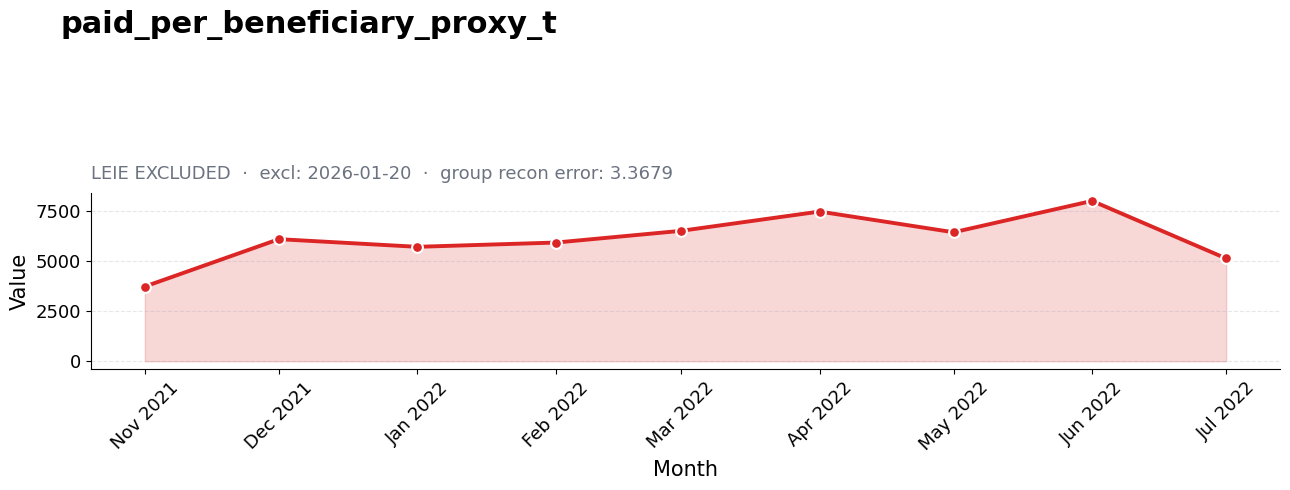

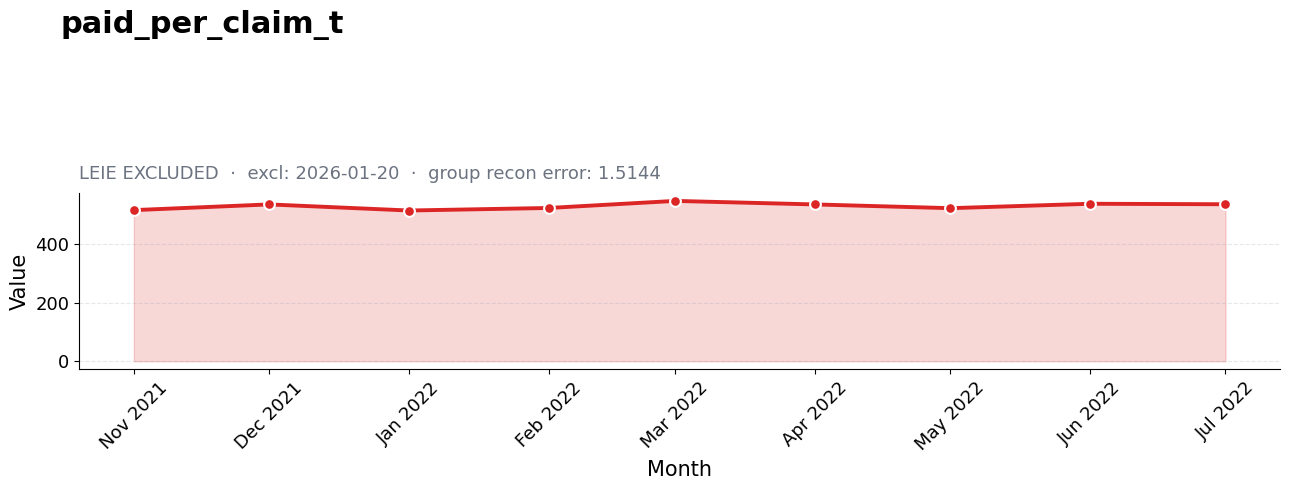

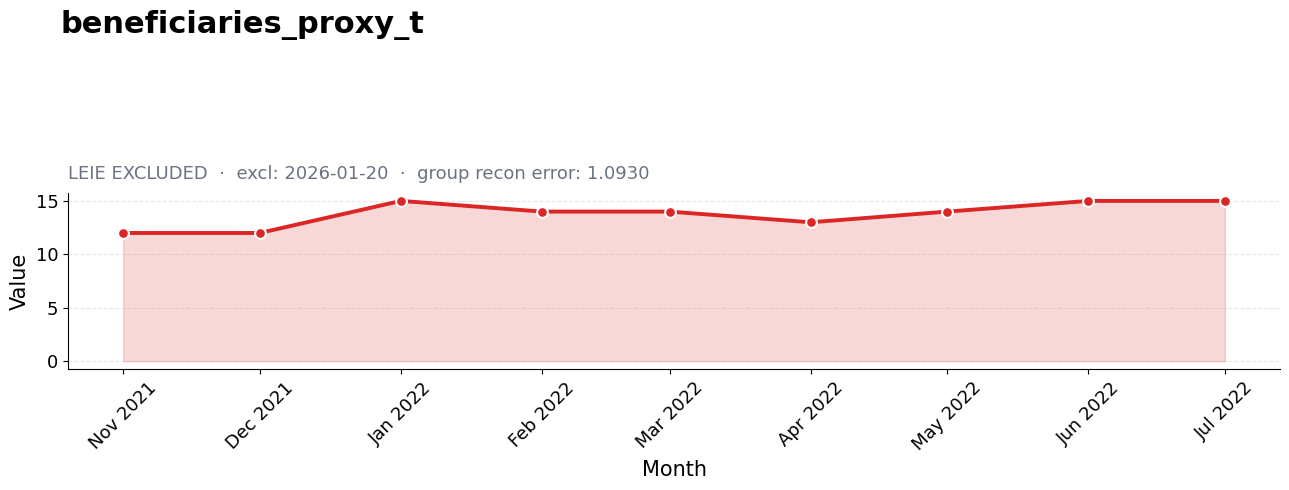

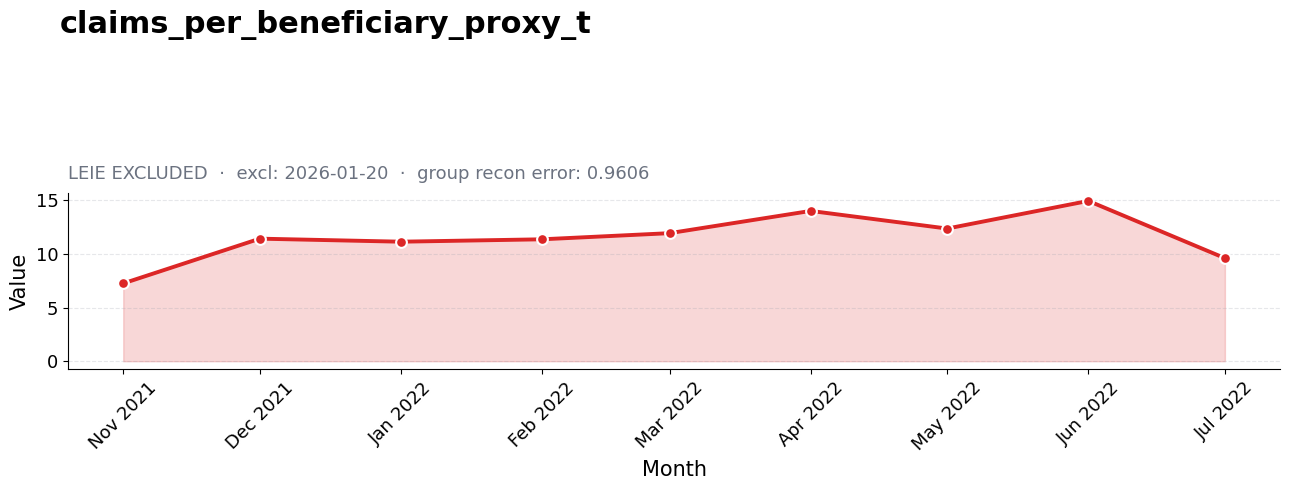

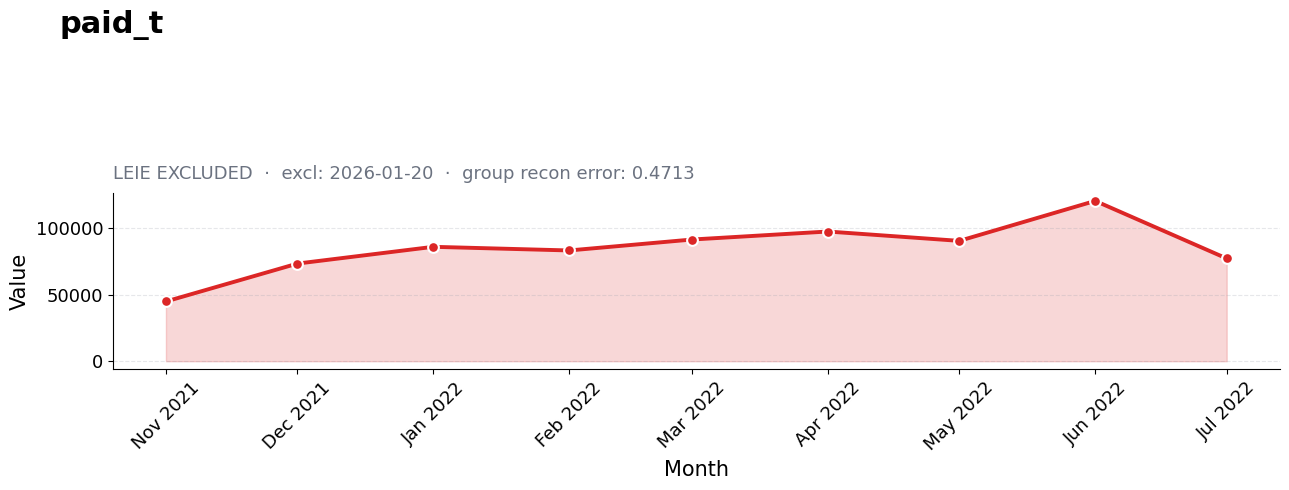

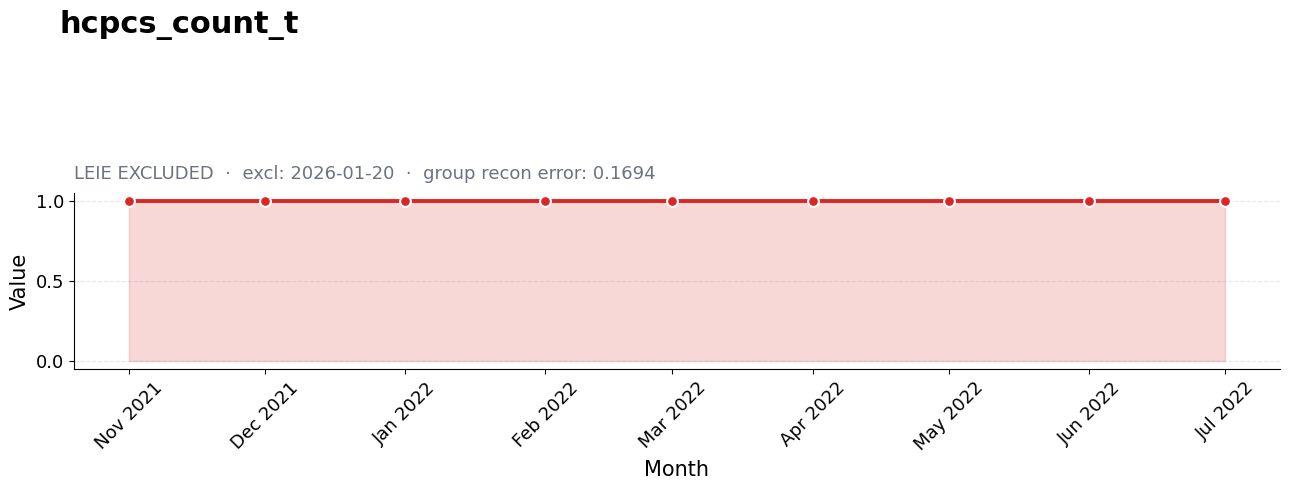

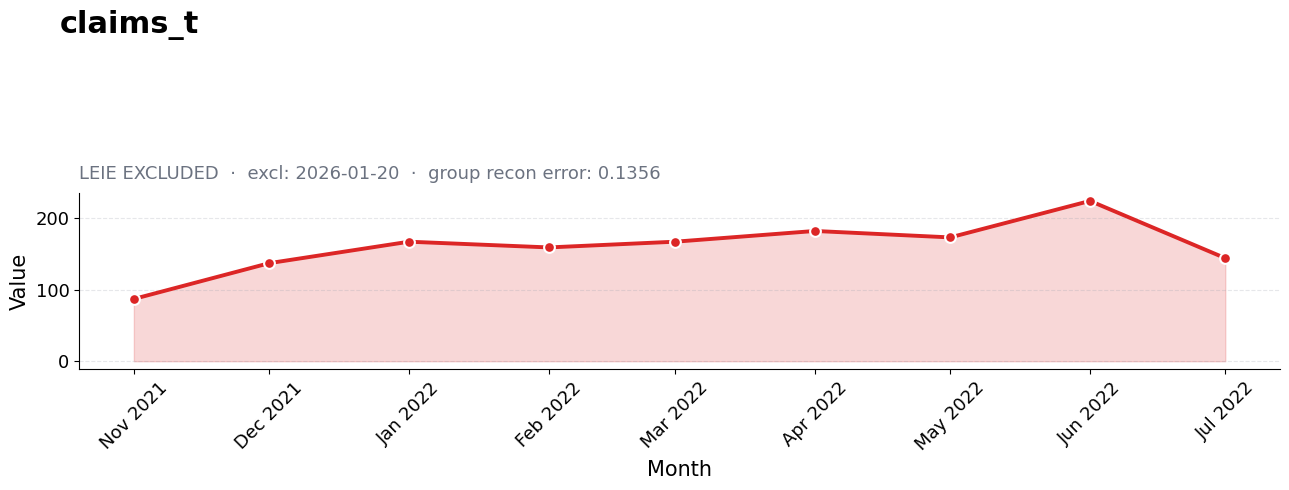

In [70]:
# ── Per-group helper: group mean reconstruction error ────────────────────
def get_group_stats(npi: str):
    """Returns dict keyed by pm_feature, sorted descending by mean reconstruction error."""
    err_row = feat_err[feat_err["billing_provider_npi"] == npi]
    if err_row.empty:
        return {}
    err_vals = err_row[err_features].iloc[0]

    group_sum   = {}
    group_count = {}
    for pl_feat, err in err_vals.items():
        pm_feat = pl_to_pm.get(pl_feat)
        if pm_feat and pm_feat in pm.columns:
            group_sum[pm_feat]   = group_sum.get(pm_feat, 0.0) + err
            group_count[pm_feat] = group_count.get(pm_feat, 0) + 1

    stats = {
        pm_feat: {"mean_err": group_sum[pm_feat] / group_count[pm_feat]}
        for pm_feat in group_sum
    }
    return dict(sorted(stats.items(), key=lambda x: x[1]["mean_err"], reverse=True))


def plot_all_features(npi: str, is_leie: bool, anomaly_score: float, excldate=None):
    """One separate figure per provider-month feature, sorted worst recon error first."""
    prov        = pm[pm["billing_provider_npi"] == npi].sort_values("month")
    group_stats = get_group_stats(npi)

    if not group_stats:
        print(f"No feature mapping found for {npi}")
        return

    color      = "#dc2626" if is_leie else "#2563eb"
    fill_color = "#fee2e2" if is_leie else "#dbeafe"

    parts = []
    if is_leie:
        parts.append("LEIE EXCLUDED")
    if excldate is not None:
        parts.append(f"excl: {excldate.date()}")

    # group_stats already sorted descending by mean_err
    for pm_feat, stats in group_stats.items():
        subtitle_parts = parts + [f"group recon error: {stats['mean_err']:.4f}"]
        subtitle = "  ·  ".join(subtitle_parts)

        fig, ax = plt.subplots(figsize=(13, 5))
        fig.patch.set_facecolor("white")
        ax.set_facecolor("white")
        plt.subplots_adjust(top=0.78)

        if not prov.empty and pm_feat in prov.columns:
            vals = prov[pm_feat]
            ax.fill_between(prov["month"], vals, alpha=0.18, color=color)
            ax.plot(prov["month"], vals, color=color, lw=2.8, zorder=3)
            ax.scatter(prov["month"], vals, s=60, color=color, zorder=4,
                       edgecolors="white", linewidths=1.5)

        fig.suptitle(pm_feat, fontsize=22, fontweight="bold", x=0.05, ha="left", y=0.97)
        ax.set_title(subtitle, fontsize=13, color="#6b7280", loc="left", pad=10)

        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
        ax.tick_params(axis="x", rotation=45, labelsize=13)
        ax.tick_params(axis="y", labelsize=13)
        ax.set_xlabel("Month", fontsize=15)
        ax.set_ylabel("Value", fontsize=15)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.25, linestyle="--", color="#9ca3af")

        plt.tight_layout(rect=[0, 0, 1, 0.78])
        plt.show()


# ── Run for TARGET_NPI ────────────────────────────────────────────────────
npi     = TARGET_NPI
score   = float(target_row["anomaly_score"])
is_leie = int(target_row["label"]) == 1

npi_rows = pm[pm["billing_provider_npi"] == npi]
_raw = npi_rows["excldate"].dropna()
excldates = pd.to_datetime(
    _raw.astype(float).astype(int).astype(str), format="%Y%m%d", errors="coerce"
).dropna()
excldate = excldates.iloc[0] if not excldates.empty else None

print(f"NPI {npi}  |  score: {score:.4f}  |  label={int(is_leie)}  |  excldate={excldate}")
plot_all_features(npi, is_leie, score, excldate)
